<a href="https://colab.research.google.com/github/iam4tart/speech-lab/blob/main/03-true-streaming-causal-model/causal_types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F

d_k is vector length (embedding dimension) of Q and K


d_k = Q.shape[-1] or K.shape[-1] by construction

In [ ]:
# usual bidirectional self-attention - sees everything
def attention(x, Wq, Wk, Wv):
  Q, K, V = x @ Wq, x @ Wk, x @ Wv
  d_k = Q.shape[-1]
  scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
  weights = F.softmax(scores, dim=-1)
  return weights @ V

In [ ]:
# causal attention - blocks the future
def causal_attention(x, Wq, Wk, Wv):
  Q, K, V = x @ Wq, x @ Wk, x @ Wv
  d_k = Q.shape[-1]
  scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)

  # x = (T, D)
  T = x.shape[0]
  future_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
  scores = scores.masked_fill(future_mask, float('-inf'))

  weights = F.softmax(scores, dim=-1)
  return weights @ V

In [ ]:
# kv cache causal attention
# x_new: (T_new, D) - only the newly arrived audio chunk
# k_cache, v_cache: (T_past, D), or None on the very first call
# returns output for just this chunk alongwith updated cache to pass into next call

# but this can cause memory to grow unboundedly that's why sliding window attention is preferred
def causal_attention_with_cache(x_new, Wq, Wk, Wv, k_cache=None, v_cache=None, max_cache=6):
  Q_new, K_new, V_new = x_new @ Wq, x_new @ Wk, x_new @ Wv

  if k_cache is None:
    K, V = K_new, V_new
  else:
    K = torch.cat([k_cache, K_new], dim=0)
    V = torch.cat([v_cache, V_new], dim=0)

  # if want to bound memory with most recent
  if K.shape[0] > max_cache:z
    K = K[-max_cache:]
    V = V[-max_cache:]

  d_k = Q_new.shape[-1]
  scores = Q_new @ K.transpose(-2, -1) / (d_k ** 0.5) # Corrected: -1,-1 to -2,-1
  weights = F.softmax(scores, dim=-1)
  output = weights @ V
  return output, K, V

In [ ]:
# sliding window attention - blocks the future and the distant past
# window decides how mant steps back is 'distant'
def sliding_window_attention(x, Wq, Wk, Wv, window=3):
  Q, K, V = x @ Wq, x @ Wk, x @ Wv
  d_k = Q.shape[-1]
  scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)

  T = x.shape[0]
  future_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
  distant_past = torch.tril(torch.ones(T, T), diagonal=-window).bool()
  scores = scores.masked_fill(future_mask | distant_past, float('-inf'))

  weights = F.softmax(scores, dim=-1)
  return weights @ V

## Further Exploration of Attention Mechanisms

Let's review the different attention mechanisms you've implemented and then demonstrate their behavior with a simple example.

### 1. Usual Bidirectional Self-Attention (`attention`)
This is the standard self-attention mechanism where every position in the sequence can attend to every other position, both past and future. It's 'bidirectional' because information flows freely in both directions.

### 2. Causal Attention (`causal_attention`)
Also known as 'masked self-attention' or 'decoder self-attention' in Transformers. In this mechanism, each position can only attend to previous positions in the sequence, and to itself. It explicitly 'blocks' attention to future tokens using a mask. This is crucial for tasks like language generation where a model should not 'see' the words it is trying to predict.

### 3. KV Cache Causal Attention (`causal_attention_with_cache`)
This is an optimization for causal attention, particularly useful during inference for sequential generation. Instead of re-calculating the Key (K) and Value (V) matrices for the entire sequence at each step, it caches the K and V from previous steps. When a new token arrives, its Query (Q) attends to the new K/V and the cached K/V. This prevents unbounded memory growth by optionally limiting the cache to a `max_cache` window.

### 4. Sliding Window Attention (`sliding_window_attention`)
This is a variation of causal attention that not only blocks future tokens but also 'distant past' tokens beyond a certain `window` size. This is useful for very long sequences where full causal attention becomes computationally expensive or memory-intensive. It assumes that the most relevant context lies within a recent window.

### Demonstration with Sample Data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# define a simple input sequence and weight matrices
# use a sequence length T=5 and embedding dimension D=4
T, D = 5, 4
x = torch.randn(T, D) # Input sequence

# create random weight matrices for Q, K, V
# in a real model, these would be learned parameters
Wq = torch.randn(D, D)
Wk = torch.randn(D, D)
Wv = torch.randn(D, D)

print("Input x shape:", x.shape)
print("Wq, Wk, Wv shapes:", Wq.shape)


Input x shape: torch.Size([5, 4])
Wq, Wk, Wv shapes: torch.Size([4, 4])


#### 1. Standard Bidirectional Attention Demo

In [ ]:
print("Output of standard attention:")
output_standard = attention(x, Wq, Wk, Wv)
print(output_standard)
print("Output shape:", output_standard.shape)


Output of standard attention:
tensor([[ 2.0384,  0.2983,  1.2197, -2.2647],
        [ 1.9710,  0.2957,  1.1853, -2.2122],
        [-0.1675, -1.3756, -0.1228,  1.5957],
        [-0.0826, -1.2976, -0.0906,  1.5202],
        [ 2.0970,  0.3014,  1.2262, -2.2828]])
Output shape: torch.Size([5, 4])


#### 2. Causal Attention Demo
Notice how the mask prevents attention to future tokens. The output for each position only depends on previous positions.

Output of causal attention:
tensor([[-0.7526,  0.0152,  0.7603, -0.8626],
        [-0.9395,  0.0987,  0.1874, -0.3443],
        [-0.8933,  0.0781,  0.3288, -0.4722],
        [ 0.9385, -0.3602,  0.2965,  0.6129],
        [ 2.0970,  0.3014,  1.2262, -2.2828]])
Output shape: torch.Size([5, 4])


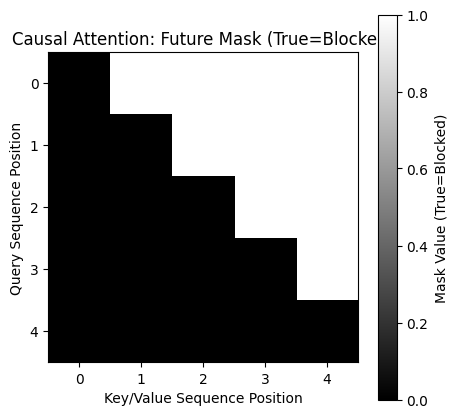

In [ ]:
print("Output of causal attention:")
output_causal = causal_attention(x, Wq, Wk, Wv)
print(output_causal)
print("Output shape:", output_causal.shape)

# future mask used in causal attention
plt.figure(figsize=(5,5))
T = x.shape[0]
future_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
plt.imshow(future_mask.cpu().numpy(), cmap='gray')
plt.title('Causal Attention: Future Mask (True=Blocked)')
plt.xlabel('Key/Value Sequence Position')
plt.ylabel('Query Sequence Position')
plt.colorbar(label='Mask Value (True=Blocked)')
plt.show()


#### 3. Sliding Window Attention Demo
This demonstrates causal attention with an additional mask for the distant past. Here, `window=2` means each token can only attend to itself and the 2 immediately preceding tokens.

Output of sliding window attention (window=2):
tensor([[-0.7526,  0.0152,  0.7603, -0.8626],
        [-0.9395,  0.0987,  0.1874, -0.3443],
        [-1.2074,  0.2184, -0.6342,  0.3990],
        [ 1.2940, -0.4545,  0.4278,  0.6733],
        [ 1.2743, -0.4674,  0.4194,  0.6911]])
Output shape: torch.Size([5, 4])


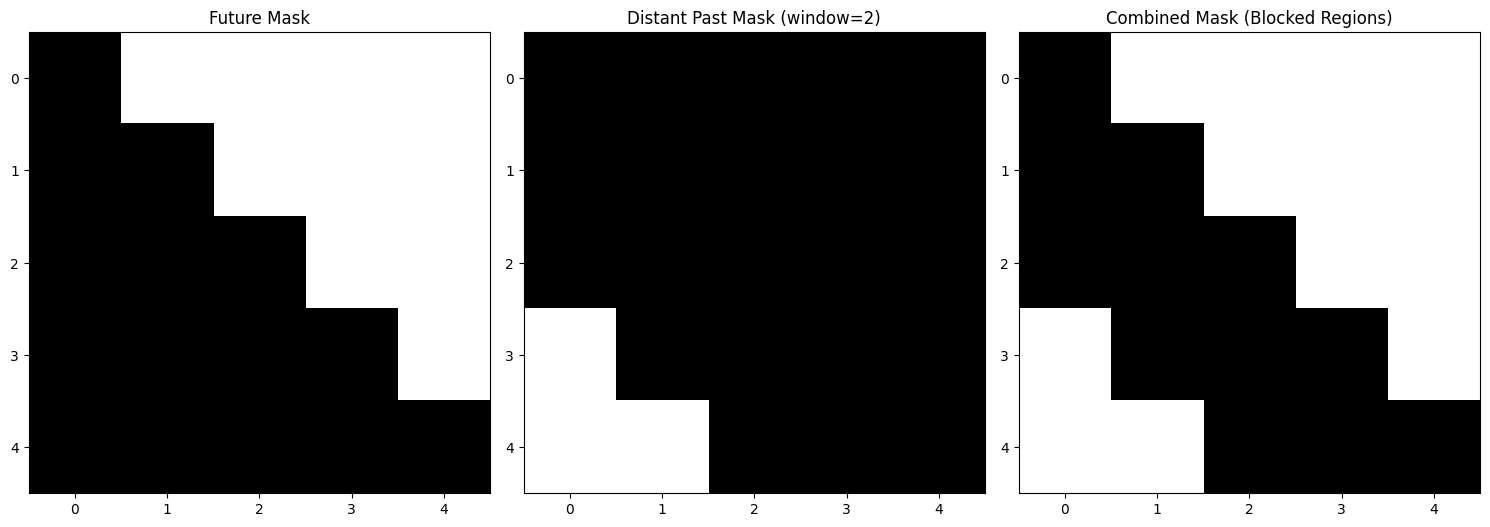

In [ ]:
print("Output of sliding window attention (window=2):")
output_sliding_window = sliding_window_attention(x, Wq, Wk, Wv, window=2)
print(output_sliding_window)
print("Output shape:", output_sliding_window.shape)

# Visualize the masks used in sliding window attention
plt.figure(figsize=(15, 5))

T = x.shape[0]
window = 2

# Future Mask
future_mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
plt.subplot(1, 3, 1)
plt.imshow(future_mask.cpu().numpy(), cmap='gray')
plt.title('Future Mask')

# Distant Past Mask
distant_past_mask = torch.tril(torch.ones(T, T), diagonal=-(window + 1)).bool()
plt.subplot(1, 3, 2)
plt.imshow(distant_past_mask.cpu().numpy(), cmap='gray')
plt.title(f'Distant Past Mask (window={window})')

# Combined Mask
combined_mask = future_mask | distant_past_mask
plt.subplot(1, 3, 3)
plt.imshow(combined_mask.cpu().numpy(), cmap='gray')
plt.title('Combined Mask (Blocked Regions)')

plt.tight_layout()
plt.show()


#### 4. KV Cache Causal Attention Demo
This demonstrates how the KV cache is built up over sequential calls. `max_cache` is set to 3 to show how the cache is truncated if it exceeds the limit.

In [ ]:
# Simulate sequential token generation
max_cache_len = 3 # Example max cache length

# First token/chunk
x_new1 = torch.randn(1, D) # A single token/chunk
print("--- First chunk ---")
output1, k_cache1, v_cache1 = causal_attention_with_cache(x_new1, Wq, Wk, Wv, max_cache=max_cache_len)
print("Output 1 shape:", output1.shape)
print("K cache 1 shape:", k_cache1.shape)
print("V cache 1 shape:", v_cache1.shape)

# Second token/chunk
x_new2 = torch.randn(1, D)
print("\n--- Second chunk ---")
output2, k_cache2, v_cache2 = causal_attention_with_cache(x_new2, Wq, Wk, Wv, k_cache1, v_cache1, max_cache=max_cache_len)
print("Output 2 shape:", output2.shape)
print("K cache 2 shape:", k_cache2.shape)
print("V cache 2 shape:", v_cache2.shape)

# Third token/chunk
x_new3 = torch.randn(1, D)
print("\n--- Third chunk ---")
output3, k_cache3, v_cache3 = causal_attention_with_cache(x_new3, Wq, Wk, Wv, k_cache2, v_cache2, max_cache=max_cache_len)
print("Output 3 shape:", output3.shape)
print("K cache 3 shape:", k_cache3.shape)
print("V cache 3 shape:", v_cache3.shape)

# Fourth token/chunk - cache should now truncate
x_new4 = torch.randn(1, D)
print("\n--- Fourth chunk (cache truncated) ---")
output4, k_cache4, v_cache4 = causal_attention_with_cache(x_new4, Wq, Wk, Wv, k_cache3, v_cache3, max_cache=max_cache_len)
print("Output 4 shape:", output4.shape)
print("K cache 4 shape:", k_cache4.shape)
print("V cache 4 shape:", v_cache4.shape)


--- First chunk ---
Output 1 shape: torch.Size([1, 4])
K cache 1 shape: torch.Size([1, 4])
V cache 1 shape: torch.Size([1, 4])

--- Second chunk ---
Output 2 shape: torch.Size([1, 4])
K cache 2 shape: torch.Size([2, 4])
V cache 2 shape: torch.Size([2, 4])

--- Third chunk ---
Output 3 shape: torch.Size([1, 4])
K cache 3 shape: torch.Size([3, 4])
V cache 3 shape: torch.Size([3, 4])

--- Fourth chunk (cache truncated) ---
Output 4 shape: torch.Size([1, 4])
K cache 4 shape: torch.Size([3, 4])
V cache 4 shape: torch.Size([3, 4])
